# 08 — Pinning the chain

The other notebooks explain what GRANDlib computes. This one is for the person
about to change it, and it answers one question: **if I alter the chain, what
will tell me the answer moved?**

Today, one thing does. `tests/sim/test_pipeline_golden.py` runs shower to
voltage on a fixed input with a fixed seed and compares against a stored
result. Everything below is an experiment on that test — what it catches, how
large a change has to be before it notices, and the one class of mistake it
would miss if the input were chosen carelessly.

Be clear what a stored reference is. It **locks in** today's answer; it does not
**validate** it. If the code is wrong today, the reference is wrong too and the
comparison will agree with it forever. Its value is that a change becomes
*visible and deliberate* — which is what you want immediately before rewriting
the thing that produces it, and Phase 6 of the recovery plan does exactly
that.

## What is actually pinned

Three detection units, a Gaussian pulse on each of the three arms, through the
antenna response, the galactic noise and the RF chain. Before comparing
anything, look at the scale — a tolerance means nothing until you know what it
is a tolerance *of*.

In [1]:
import json, logging, tempfile, pathlib
import numpy as np
import matplotlib.pyplot as plt

# ROOT announces every tree it creates; those lines would sit between each
# command below and its answer.
logging.getLogger("grand").setLevel(logging.ERROR)

import tests.sim.test_pipeline_golden as golden

with np.load(golden.GOLDEN, allow_pickle=False) as data:
    reference = data["voltage"]
    provenance = json.loads(str(data["provenance"]))

print("produced by GRANDlib", provenance["grandlib_version"],
      "at", provenance["commit"])
print("seed", provenance["seed"], " params", provenance["params"])
print()
print("shape        ", reference.shape, "  (unit, arm, sample)")
print("peak         %8.1f uV" % np.abs(reference).max())

produced by GRANDlib 0.1.0.dev1 at d0778f56ae8c
seed 0  params {'add_noise': True, 'add_rf_chain': True, 'lst': 18.0}

shape         (3, 3, 512)   (unit, arm, sample)
peak           6063.9 uV


The reference carries its own provenance — version, commit, seed and
configuration. That is not bureaucracy: three galactic-noise tables arrived in
this repository as bare `.npy` files with no record of how they were made, and
closing that gap took a round trip to their author. A file whose whole purpose
is to be compared against is the last place to repeat it.

Now the scale. The pulse sits on a galactic-noise floor, and the ratio between
them is what decides whether a given perturbation is detectable at all.

In [2]:
# The noise floor: sample the tail, away from the pulse.
tail = reference[:, :, 400:]
floor = tail.std()

print("noise floor  %8.2f uV  (RMS, samples 400-511)" % floor)
print("peak         %8.1f uV" % np.abs(reference).max())
print("ratio        %8.0f" % (np.abs(reference).max() / floor))
print()
print("a 1e-9 relative tolerance is %.2e uV — far below the noise floor,"
      % (1e-9 * np.abs(reference).max()))
print("so the test is pinning the exact realisation, not a statistical level.")

noise floor   1209.19 uV  (RMS, samples 400-511)
peak           6063.9 uV
ratio               5

a 1e-9 relative tolerance is 6.06e-06 uV — far below the noise floor,
so the test is pinning the exact realisation, not a statistical level.


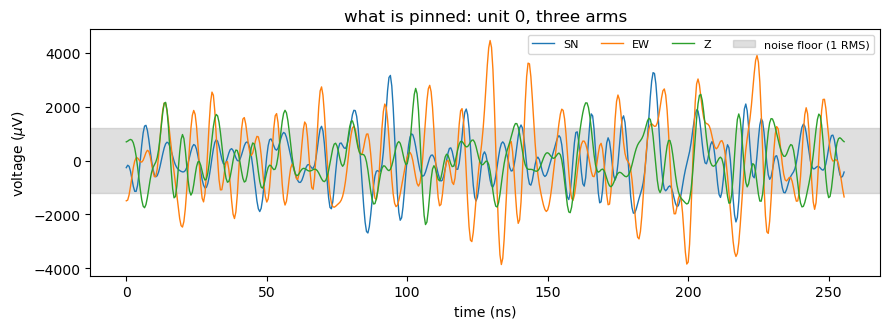

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.4))
t_ns = np.arange(reference.shape[2]) * golden.T_BIN_NS
for arm, name in enumerate(("SN", "EW", "Z")):
    ax.plot(t_ns, reference[0, arm], lw=1, label=name)
ax.axhspan(-floor, floor, color="grey", alpha=0.25,
           label="noise floor (1 RMS)")
ax.set_xlabel("time (ns)"); ax.set_ylabel(r"voltage ($\mu$V)")
ax.set_title("what is pinned: unit 0, three arms")
ax.legend(fontsize=8, ncol=4); fig.tight_layout()

## Reproducing it

Same input, same seed, same configuration.

In [4]:
def run(seed=golden.SEED, **overrides):
    """Runs the chain once and returns the voltage traces."""
    from grand import Efield2Voltage
    work = pathlib.Path(tempfile.mkdtemp())
    efield = golden._build_input(work)
    signal = Efield2Voltage(efield, str(work / "v.root"), seed=seed)
    params = dict(golden.PARAMS); params.update(overrides)
    signal.params.update(params)
    signal.compute_voltage()
    return np.asarray(signal.vout, dtype=np.float64)


fresh = run()
print("largest disagreement with the reference: %g uV"
      % np.abs(fresh - reference).max())

largest disagreement with the reference: 0 uV


Exactly zero — bit for bit, not nearly. The $10^{-9}$ tolerance in the test
exists so that a NumPy or BLAS upgrade reassociating a floating-point sum does
not fail the build; nothing here needs it today.

## What it catches, for real

The interesting question is not whether the comparison works but **what size of
mistake it detects**. So: change the chain, genuinely, and measure. Each row
below re-runs the whole simulation with one thing different.

In [5]:
rows = []
for label, seed, over in [
        ("nothing (control)",            golden.SEED, {}),
        ("galactic noise switched off",  golden.SEED, dict(add_noise=False)),
        ("RF chain switched off",        golden.SEED, dict(add_rf_chain=False)),
        ("sidereal time 18 h -> 19 h",   golden.SEED, dict(lst=19.0)),
        ("a different noise seed",       1,           {}),
]:
    out = run(seed=seed, **over)
    delta = np.abs(out - reference).max()
    caught = not np.allclose(out, reference, rtol=1e-9, atol=0.0)
    rows.append((label, delta, delta / np.abs(reference).max(), caught))

print("%-30s %12s %10s   %s" % ("change", "max |diff|", "relative", "caught?"))
for label, delta, rel, caught in rows:
    # The control has nothing to catch, so "no" there is the right answer
    # rather than a failure; say so instead of printing a bare NO.
    verdict = "yes" if caught else ("--" if delta == 0 else "MISSED")
    print("%-30s %9.4g uV %9.3g   %s" % (label, delta, rel, verdict))

change                           max |diff|   relative   caught?
nothing (control)                      0 uV         0   --
galactic noise switched off         6071 uV         1   yes
RF chain switched off               6038 uV     0.996   yes
sidereal time 18 h -> 19 h         146.7 uV    0.0242   yes
a different noise seed              8111 uV      1.34   yes


Two of those deserve comment.

**A different seed changes the answer by more than switching the noise off.**
That is not a bug: a fresh seed draws a completely different noise realisation,
statistically identical but numerically unrelated. It is the clearest
demonstration that this test pins one particular realisation, not a physical
level. Change the seed deliberately and the test fails, correctly.

**One hour of sidereal time moves the answer by 2 %.** The sky is not uniform,
so the galactic background genuinely differs. Small, real, and well above the
tolerance.

## The mistake the input is designed to catch

The reference input is deliberately asymmetric — the three arms carry the same
pulse at amplitudes 1.0, 0.6 and 0.2.

That looked fussy when it was written. It is the difference between catching a
swapped antenna arm and not, and it can be shown rather than argued.

In [6]:
from grand import Efield2Voltage
from grand.dataio.event_trees import TEfield, TShower
from grand.dataio.run_trees import TRun


def run_with_amplitudes(amplitudes, swap_two_arms=False):
    """Builds an input with the given per-arm amplitudes and runs the chain."""
    work = pathlib.Path(tempfile.mkdtemp())
    path = str(work / "e.root")

    trun = TRun(path)
    trun.run_number = 0
    trun.du_id = list(range(golden.N_DU))
    trun.du_xyz = [[0., 0., 0.], [500., 0., 0.], [0., 500., 0.]]
    trun.t_bin_size = [golden.T_BIN_NS] * golden.N_DU
    trun.origin_geoid = golden.SITE
    trun.fill(); trun.write()

    t = np.arange(golden.N_SAMPLES) * golden.T_BIN_NS
    pulse = np.exp(-((t - golden.PEAK_NS) ** 2) / (2 * golden.WIDTH_NS ** 2))
    amps = list(amplitudes)
    if swap_two_arms:
        amps[0], amps[1] = amps[1], amps[0]      # SN <-> EW
    trace = np.stack([np.stack([pulse * a for a in amps])
                      for _ in range(golden.N_DU)]).astype(np.float32)

    efield = TEfield(path)
    efield.run_number, efield.event_number = 0, 0
    efield.du_id = list(range(golden.N_DU))
    efield.du_nanoseconds = [0] * golden.N_DU
    efield.du_seconds = [0] * golden.N_DU
    efield.trace = trace
    efield.fill(); efield.write()

    shower = TShower(path)
    shower.run_number, shower.event_number = 0, 0
    shower.zenith, shower.azimuth = 85.0, 0.0
    shower.energy_primary = 3.98e9
    shower.shower_core_pos = [0.0, 0.0, 1200.0]
    shower.xmax_pos_shc = [0.0, 0.0, 10000.0]
    shower.fill(); shower.write()

    signal = Efield2Voltage(path, str(work / "v.root"), seed=golden.SEED)
    signal.params.update(golden.PARAMS)
    signal.compute_voltage()
    return np.asarray(signal.vout, dtype=np.float64)


for name, amps in [("asymmetric  1.0 / 0.6 / 0.2   (what we use)", (1.0, 0.6, 0.2)),
                   ("symmetric   1.0 / 1.0 / 1.0", (1.0, 1.0, 1.0))]:
    normal = run_with_amplitudes(amps)
    swapped = run_with_amplitudes(amps, swap_two_arms=True)
    delta = np.abs(normal - swapped).max()
    print("%-44s swap changes it by %8.4g uV   %s"
          % (name, delta, "detected" if delta > 0 else "INVISIBLE"))

asymmetric  1.0 / 0.6 / 0.2   (what we use)  swap changes it by    5.005 uV   detected


symmetric   1.0 / 1.0 / 1.0                  swap changes it by        0 uV   INVISIBLE


With a symmetric input, swapping two antenna arms changes **nothing** — the
error passes straight through the regression and every other test in the suite.
With the asymmetric input it shows up.

The change is small, about 0.1 % of the peak, but the comparison is exact, so
size does not matter — only that it is non-zero.

This is the general lesson, and it outlives this notebook: **a regression test
is only as good as the asymmetry of its input.** Symmetric inputs hide exactly
the class of bug — swapped components, transposed indices, mis-ordered units —
that is hardest to find by reading code.

## When it fails

A failure prints the version and commit that made the reference, and the
location and size of the largest disagreement. The question is then which of
two things happened.

**You meant it.** A corrected constant, a new antenna model, a deliberate
change to the chain. The galactic-noise fix of 2026-09-07 was one of these: it
moved every voltage by $\sqrt2$, correctly. Regenerate, and say why in the
commit message:

```
python tests/sim/test_pipeline_golden.py --write
```

**You did not.** Then the failure is the point, and the numbers above are how
you locate it. Compare the size and shape of the disagreement against the
table: a factor of order one suggests a stage switched on or off, a couple of
per cent suggests a changed input or configuration, and something confined to
one arm suggests an indexing error.

**Do not regenerate first.** The reference is the only record of what the
answer used to be, and overwriting it destroys the evidence you need.

## What this cannot tell you

That the chain is right. Nothing in this repository establishes that end to
end. The closest is the galactic-noise level, rebuilt independently from the
shipped tables and the documented relation (notebook 05).

An external check means reproducing a published result, which needs the inputs
behind it to still exist. Until someone confirms they do, this is what stands
between a refactor and a silently different answer.

## Where next

- [06 — From electric field to ADC](06_efield_to_adc.ipynb) — the chain being pinned here
- [05 — Galactic noise](05_galactic_noise.ipynb) — the one stage checked against its own inputs
- [04 — The RF chain](04_rf_chain.ipynb) — where most of the pulse shape comes from

<!-- provenance -->
---

*Generated by `notebooks/make_notebooks.py` on 2026-09-08 10:07 UTC, from commit `3ae3735`, running Python 3.12.14. Edit the generator and rebuild rather than editing this file: a notebook edited in place is overwritten by the next build, and `--check` will say so.*